In [1]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
from utils import simulate_bagging_and_ijk_var_calculation
import pandas as pd

In [2]:

####### Simulation parameters  #########
n_x = 1000
n_sim = 2000
portion_non_zero_weights = 0.5
var_x = 1
seed = 41

B_values = [500, 1000, 2000, 4000, 10000]  # Different B values

# Prepare to collect results
results = []

# Loop over each B value
for B in B_values:
    print(f"Running simulations for B = {B}")
    # run simulation
    with ProcessPoolExecutor() as executor:
        rng = np.random.default_rng(seed)
        weights = np.zeros(n_x)

        m = int(n_x * portion_non_zero_weights)         # number of non-zero weights
        x_sim = rng.normal(0, var_x**0.5, (n_sim, n_x)) # simulate n_sim data-sets
        weights[:m] = 1 / m                             # weights for the first m variables = 1/m , else 0

        ijk_jahn = np.zeros(n_sim)
        ijk_wager = np.zeros(n_sim)
        ijk_jahn_u = np.zeros(n_sim)
        ijk_wager_u = np.zeros(n_sim)
        jk_wager = np.zeros(n_sim)
        jk_wager_u = np.zeros(n_sim)

        futures = [
            executor.submit(
                simulate_bagging_and_ijk_var_calculation,
                x1=x_sim[i],
                B=B,
                sim_i=i,
                seed=seed,
                weights=weights,
                m=m,
            )
            for i in range(n_sim)
        ]

        for i, future in enumerate(tqdm(futures, desc=f"Simulations for B={B}", unit="simulation")):
            _ijk_jahn, _ijk_jahn_u, _ijk_wager, _ijk_wager_u, _jk_wager, _jk_wager_u = future.result()

            ijk_jahn[i] = _ijk_jahn
            ijk_jahn_u[i] = _ijk_jahn -  _ijk_jahn_u
            ijk_wager[i] = _ijk_wager
            ijk_wager_u[i] = _ijk_wager - _ijk_wager_u
            jk_wager[i] = _jk_wager
            jk_wager_u[i] = _jk_wager - _jk_wager_u

        true_variance = var_x / m


        # Collect the results
        results.append({
            'Bootstrap Samples (B)': B,
            'True Variance': f"{true_variance:.3f}",
            'ijk_jahn ± Std': f"{ijk_jahn.mean():.4f} ± {ijk_jahn.std(ddof=1):.4f}",
            'ijk_jahn_u ± Std': f"{ijk_jahn_u.mean():.4f} ± {ijk_jahn_u.std(ddof=1):.4f}",
            'ijk_wager ± Std': f"{ijk_wager.mean():.4f} ± {ijk_wager.std(ddof=1):.4f}",
            'ijk_wager_u ± Std': f"{ijk_wager_u.mean():.4f} ± {ijk_wager_u.std(ddof=1):.4f}",
            'jk_wager ± Std': f"{jk_wager.mean():.4f} ± {jk_wager.std(ddof=1):.4f}",
            'jk_wager_u ± Std': f"{jk_wager_u.mean():.4f} ± {jk_wager_u.std(ddof=1):.4f}",
        })

df_results = pd.DataFrame(results)
df_results.to_csv("results.csv", index=False)


Running simulations for B = 500


Simulations for B=500: 100%|██████████| 2000/2000 [00:14<00:00, 142.32simulation/s]


Running simulations for B = 1000


Simulations for B=1000: 100%|██████████| 2000/2000 [00:26<00:00, 76.77simulation/s]


Running simulations for B = 2000


Simulations for B=2000: 100%|██████████| 2000/2000 [00:56<00:00, 35.54simulation/s]


Running simulations for B = 4000


Simulations for B=4000: 100%|██████████| 2000/2000 [01:44<00:00, 19.20simulation/s]


Running simulations for B = 10000


Simulations for B=10000: 100%|██████████| 2000/2000 [04:23<00:00,  7.60simulation/s]


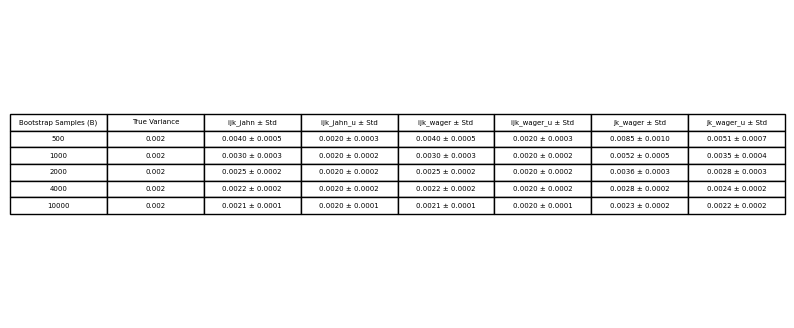

In [6]:
import matplotlib.pyplot as plt

path = r'C:\Users\rehan\meine_Repos\Masterarbeit\Chapter 2.5.3__Figure2.11__Table2.1\Table_2.1\results.csv'
data = pd.read_csv(path)

# Bildgröße festlegen
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Tabelle zeichnen
table = ax.table(cellText=data.values,
                 colLabels=data.columns,
                 cellLoc='center',
                 loc='center')

# Tabelle als Bild speichern
image_path = "bagged_mean_estimator.png"
plt.savefig(r'C:\Users\rehan\meine_Repos\Masterarbeit\Paper\help_figures\bagged_mean_estimator.png', dpi=300, bbox_inches='tight')
plt.show()